In [ ]:
import os
from google.colab import files

# 1. Create the folder structure required by the assignment
os.makedirs('/content/part_a', exist_ok=True)
os.makedirs('/content/data', exist_ok=True)

# 2. Upload your CSV files from your computer
print("Please upload q1_heart_disease.csv, q2_customers.csv, and q3_retail_promotions.csv:")
uploaded = files.upload()

# 3. Move the uploaded files into the 'data' folder
for filename in uploaded.keys():
    os.rename(filename, f"/content/data/{filename}")

# 4. Change the working directory to 'part_a'
# This is crucial so that '../data/' points to the correct location
os.chdir('/content/part_a')
print("\nEnvironment setup complete. You are now working inside 'part_a'.")

Please upload q1_heart_disease.csv, q2_customers.csv, and q3_retail_promotions.csv:


Saving q1_heart_disease.csv to q1_heart_disease.csv

Environment setup complete. You are now working inside 'part_a'.


Shape: (800, 12)
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


ValueError: could not convert string to float: 'atypical_angina'

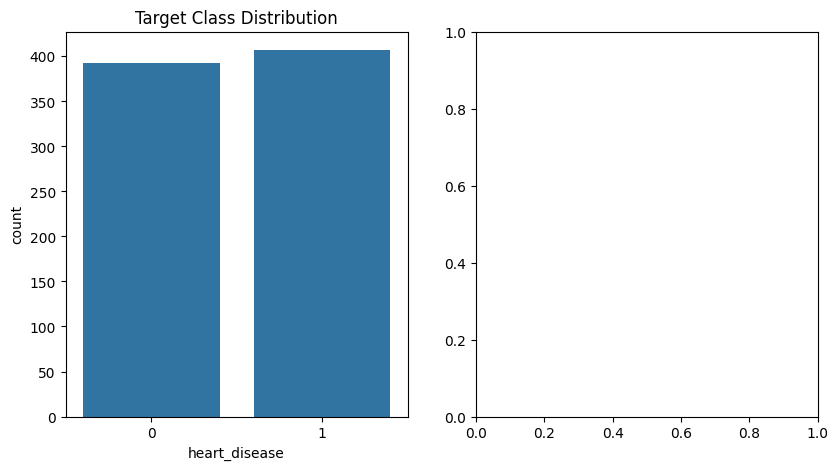

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# 1. Data Loading and Inspection
df = pd.read_csv('../data/q1_heart_disease.csv')
print(f"Shape: {df.shape}")
print(df.dtypes)
print(f"\nMissing Values:\n{df.isnull().sum()}")
display(df.head())

# 2. Exploratory Data Analysis
plt.figure(figsize=(15, 5))

# Target distribution
plt.subplot(1, 3, 1)
sns.countplot(x='heart_disease', data=df)
plt.title('Target Class Distribution')

# Correlation Heatmap
plt.subplot(1, 3, 2)
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')

# Age vs Max HR
plt.subplot(1, 3, 3)
sns.scatterplot(x='age', y='max_hr', hue='heart_disease', data=df)
plt.title('Age vs Max HR')
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer # Added for NaN handling
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# 3. Data Preprocessing
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# One-hot encoding and scaling
categorical_features = ['sex', 'chest_pain_type', 'fasting_bs', 'resting_ecg', 'exercise_angina', 'st_slope']
numeric_features = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. Model Training
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 5. Evaluation
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"\n--- {name} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


--- Decision Tree ---
[[55 24]
 [21 60]]
              precision    recall  f1-score   support

           0       0.72      0.70      0.71        79
           1       0.71      0.74      0.73        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160


--- Random Forest ---
[[63 16]
 [16 65]]
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        79
           1       0.80      0.80      0.80        81

    accuracy                           0.80       160
   macro avg       0.80      0.80      0.80       160
weighted avg       0.80      0.80      0.80       160



ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values